<a href="https://colab.research.google.com/github/smithve-laf/smith-repository-notebook/blob/main/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Tori Smith
#####*Intro to Neural Data Analysis*
#####**04/10/2026**

In [ ]:
#step 2
#importing modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
#step 3
#uploading data
url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'

fear_traces = np.loadtxt(url1, delimiter = ',')
extinction_predictors = np.loadtxt(url2, delimiter = ',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)

#notes from class
#extinction traces should be same size as the predictors for the extinction section
#graph we are making 63 neurons, 63 times for conditioning section, a bunch of r squared value, the bigger it is the more response to shock and tone
#if neuron responds more to shock and tone, it cares more about forming the memory
#for the extinction section, a bunch of traces, then have predictors variable he gives us, correlating these two things to get r squared value
#higher the r squared, the more the neuron cares about the extinction memory

#making a graph of r squared values from conditioning section, then again for extinction section
#because these are the same neurons, do neurons that care about learning also care about extinquishing it, are they the same or are they seperate
#if a neuron has a high r squared value for both, the same neurons learn the associated and extinguish it.

In [ ]:
#step 5
#making two new variables
print(fear_traces.shape)

conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]

(24668, 63)


In [ ]:
#step 6
#size of arrays
print(conditioning_traces.size)
print(extinction_traces.size)
#size gives total values in array
#shape gives rows x columns
print(conditioning_traces.shape)
print(extinction_traces.shape)

#samples is in rows

658854
895230
(10458, 63)
(14210, 63)


In [ ]:
#step 7
#time variables
time_conditioning = np.linspace(0, 10458/15, 10458)
time_extinction = np.linspace(0, 14210/15, 14210)

#first number 0, second number length of samples divided by sampling rate (15), last number length of samples

#####8. Number of ROIs (cells) imaged during the sessions is 63. Total length of time conditioning: 10458/15 = **697.2 sec**/60 = **11.62 minutes**. Total length of time extinction: 14210/15 = **947.33 sec** / 60 = **15.79 minutes**.

Text(0.5, 1.0, 'Extinction Session')

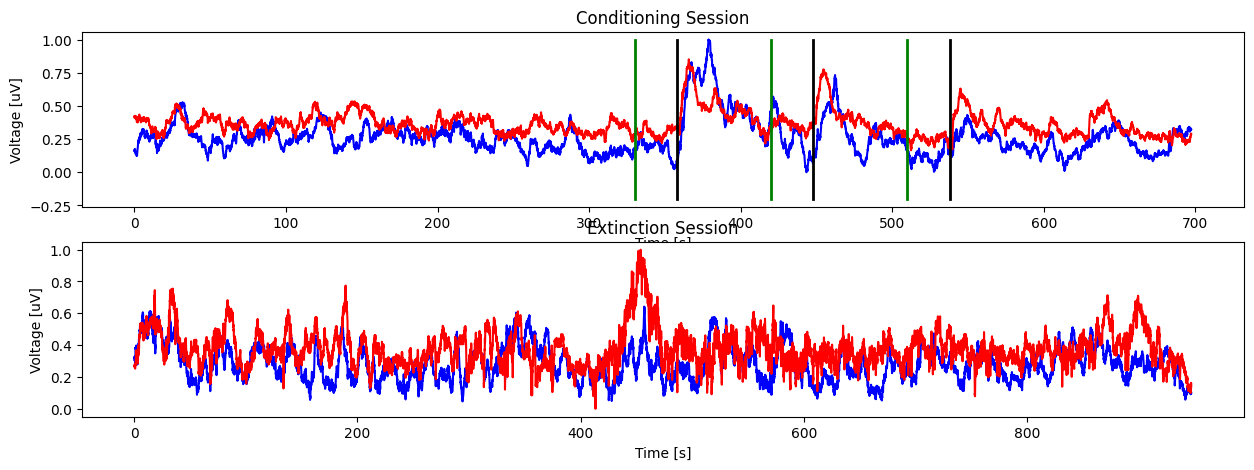

In [ ]:
#step 9
#ploting ROIs
#conditioning plot
fig, ax = plt.subplots(2,1, figsize = (15,5))
ax[0].plot(time_conditioning,conditioning_traces[:,0], 'b')
ax[0].plot(time_conditioning,conditioning_traces[:,1], 'r')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Voltage [uV]')
ax[0].set_title('Conditioning Session')

#vertical lines shock
ax[0].plot([shock_index[0], shock_index[0]], [-0.2,1], 'k', lw=2)
ax[0].plot([shock_index[1], shock_index[1]], [-0.2,1], 'k', lw=2)
ax[0].plot([shock_index[2], shock_index[2]], [-0.2,1], 'k', lw=2)

#vertical lines tone
ax[0].plot([tone_index[0], tone_index[0]], [-0.2,1], 'g', lw=2)
ax[0].plot([tone_index[1], tone_index[1]], [-0.2,1], 'g', lw=2)
ax[0].plot([tone_index[2], tone_index[2]], [-0.2,1], 'g', lw=2)

#extinction plot
ax[1].plot(time_extinction,extinction_traces[:,0], 'b')
ax[1].plot(time_extinction,extinction_traces[:,1], 'r')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Voltage [uV]')
ax[1].set_title('Extinction Session')

#####For the first ROI in blue, during the conditioning session there is a large spike after the first shock and some spikes after the next ones. In the extinction condition there is less of a pattern/its hard to tell where the shocks are without lines. For the second ROI in the conditioning session, it seems like the traces spike closer to the tone or really quickly after the shock. In the extinction session, there isnt much of a pattern but there is a large spike after the second tone.

In [ ]:
#step 12
from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

#making our shock_array and tone_array variables
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

#predictors_conditioning
predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array, 'shock onset': shock_array})
print(predictors_conditioning.shape)

(10458, 3)


In [ ]:
#step 13
#conditioning_traces loop correlation coefficient
r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]   #fit GLM (Poisson) using predictors_conditioning
  model = sm.GLM(trace_temp, predictors_conditioning, family=sm.families.Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()  #create predicted trace
  r = pearsonr(trace_temp, predicted_trace) #create correlation between predicted and actual trace
  r_model_conditioning[i] = r.statistic #store correlation in the array

In [ ]:
#step 14
#extinction_traces loop correlation coefficient

#making our shock_array and tone_array variables for extinction (14210)
shock_array2 = np.zeros(14210)
for i in range(14210):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array2[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array2[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array2[i] = 1
  else:
    shock_array2[i] = 0

tone_array2 = np.zeros(14210)
for i in range(14210):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array2[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array2[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array2[i] = 1
  else:
    tone_array2[i] = 0

#extinction_predictors
extinction_predictors = df(data={'Intercept': np.ones_like(tone_array2), 'tone onset': tone_array2, 'shock onset': shock_array2})
print(extinction_predictors.shape) #just checking
r_index_extinction = np.zeros(63)

for i in range(63):
  trace_temp2 = extinction_traces[:,i]   #fit GLM (Poisson) using predictors_extinction
  model2 = sm.GLM(trace_temp2, extinction_predictors, family=sm.families.Poisson())
  model2_results = model2.fit()
  predicted_trace2 = model2_results.predict()  #create predicted trace
  r2 = pearsonr(trace_temp2, predicted_trace2) #create correlation between predicted and actual trace
  r_index_extinction[i] = r2.statistic #store correlation in the array

(14210, 3)


In [ ]:
#step 15
#correlate r_index_conditioning and r_index_extinction variables
print(r_model_conditioning)
print(r_index_extinction) #was getting error, printed each to make sure i wasnt getting zeros

r_final = pearsonr(r_model_conditioning, r_index_extinction)
print(r_final)

[0.44953049 0.50474176 0.55814187 0.35981383 0.41840453 0.50268583
 0.49943597 0.39656461 0.44804219 0.42958841 0.4642391  0.36850245
 0.52526383 0.41636814 0.42683675 0.39252917 0.41005673 0.39343021
 0.3574375  0.46265713 0.37248472 0.52415508 0.42404404 0.30825484
 0.38836014 0.06887754 0.30097893 0.38360513 0.14103351 0.36222132
 0.28545351 0.32591809 0.3208561  0.38127741 0.26477989 0.33264007
 0.20011157 0.28925042 0.36106922 0.17979107 0.10777468 0.27791796
 0.2600379  0.42324272 0.19962854 0.1667966  0.36970096 0.26764578
 0.17218204 0.25167449 0.28372995 0.23717542 0.12876419 0.15086474
 0.19840049 0.09601824 0.09738203 0.12979155 0.05378718 0.14751203
 0.22792264 0.31060172 0.27605328]
[0.19712629 0.24294441 0.16102413 0.19287868 0.20632479 0.08250424
 0.26904637 0.34898219 0.34847102 0.15370425 0.08275323 0.3188994
 0.11971082 0.25891056 0.32191282 0.07046759 0.22994756 0.14989501
 0.03597375 0.13247257 0.08646045 0.32096521 0.30253936 0.19017583
 0.23774055 0.12763436 0.163

Text(0.5, 1.0, 'ROI Correlation')

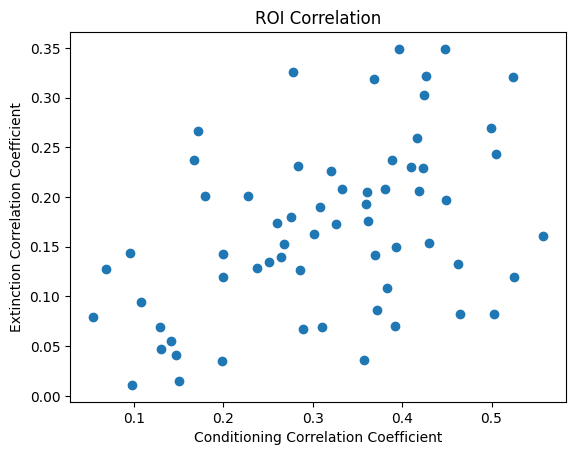

In [ ]:
#step 16
#scatterplot
plt.scatter(r_model_conditioning, r_index_extinction)
plt.xlabel('Conditioning Correlation Coefficient')
plt.ylabel('Extinction Correlation Coefficient')
plt.title('ROI Correlation')

#####The correlation coefficient for this data is 0.44. This means that there is a moderate positive correlation, which suggests that ROIs that respond strongly during conditioning tend to also respond moderately during extinction. You can see on the scatterplot that the points are somewhat scattered but there is still a visible upward trend. The p-value for my correlation coefficient = 0.000307, which tells us that the data is significant.

#####